In [1]:
import pandas as pd
import numpy as np

In [2]:
df_train = pd.read_csv("train.csv")

In [3]:
null_columns = df_train.columns[df_train.isnull().sum() >= 1]

In [4]:
df_train.duplicated().sum()

0

In [5]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,YrSold,SaleType,SaleCondition,SalePrice,houseage,houseremodelage,totalsf,totalarea,totalbaths,totalporchsf
0,1.0,60.0,RL,65.0,8450.0,Pave,Na,Reg,Lvl,AllPub,...,2008.0,WD,Normal,208500.0,5.0,5.0,2416.0,2566.0,3.5,61.0
1,2.0,20.0,RL,80.0,9600.0,Pave,Na,Reg,Lvl,AllPub,...,2007.0,WD,Normal,181500.0,31.0,31.0,2240.0,2524.0,2.0,298.0
2,3.0,60.0,RL,68.0,11250.0,Pave,Na,IR1,Lvl,AllPub,...,2008.0,WD,Normal,223500.0,7.0,6.0,2272.0,2706.0,3.5,42.0
3,4.0,70.0,RL,60.0,9550.0,Pave,Na,IR1,Lvl,AllPub,...,2006.0,WD,Abnorml,140000.0,91.0,36.0,1933.0,2473.0,2.0,35.0
4,5.0,60.0,RL,84.0,14260.0,Pave,Na,IR1,Lvl,AllPub,...,2008.0,WD,Normal,250000.0,8.0,8.0,2853.0,3343.0,3.5,276.0


In [6]:
# Select categorical columns
categorical_cols = df_train.select_dtypes(include=['object']).columns

In [7]:
# LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in categorical_cols:
    df_train[col] = le.fit_transform(df_train[col])

In [8]:
df_train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,YrSold,SaleType,SaleCondition,SalePrice,houseage,houseremodelage,totalsf,totalarea,totalbaths,totalporchsf
0,1.0,60.0,3,65.0,8450.0,1,1,3,3,0,...,2008.0,8,4,208500.0,5.0,5.0,2416.0,2566.0,3.5,61.0
1,2.0,20.0,3,80.0,9600.0,1,1,3,3,0,...,2007.0,8,4,181500.0,31.0,31.0,2240.0,2524.0,2.0,298.0
2,3.0,60.0,3,68.0,11250.0,1,1,0,3,0,...,2008.0,8,4,223500.0,7.0,6.0,2272.0,2706.0,3.5,42.0
3,4.0,70.0,3,60.0,9550.0,1,1,0,3,0,...,2006.0,8,0,140000.0,91.0,36.0,1933.0,2473.0,2.0,35.0
4,5.0,60.0,3,84.0,14260.0,1,1,0,3,0,...,2008.0,8,4,250000.0,8.0,8.0,2853.0,3343.0,3.5,276.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456.0,60.0,3,62.0,7917.0,1,1,3,3,0,...,2007.0,8,4,175000.0,8.0,7.0,1647.0,2600.0,2.5,40.0
1456,1457.0,20.0,3,85.0,13175.0,1,1,3,3,0,...,2010.0,8,4,210000.0,32.0,22.0,2863.0,3615.0,3.0,349.0
1457,1458.0,70.0,3,66.0,9042.0,1,1,3,3,0,...,2010.0,8,4,266500.0,69.0,4.0,2615.0,3492.0,2.0,60.0
1458,1459.0,20.0,3,68.0,9717.0,1,1,3,3,0,...,2010.0,8,4,142125.0,60.0,14.0,1127.0,2156.0,2.0,366.0


## FEATURES SELECTION

In [9]:
features = df_train.drop('SalePrice', axis=1)
target = df_train['SalePrice']

In [10]:
def correlation(dataset, threshold):
    correlated_pairs = []
    corr_matrix = dataset.corr()

    for i, col1 in enumerate(corr_matrix.columns):
        for col2 in corr_matrix.columns[i + 1:]:
            if abs(corr_matrix.loc[col1, col2]) > threshold:
                correlated_pairs.append((col1, col2, corr_matrix.loc[col1, col2]))

    return correlated_pairs

corr_pairs = correlation(features, 0.6)

In [11]:
# Calculate correlation between strongly correlated feature pairs and target variable
corr_with_target = {}
for col1, col2, corr in corr_pairs:
    corr_with_target[col1] = features[col1].corr(target)
    corr_with_target[col2] = features[col2].corr(target)

In [12]:
# Filter weakly correlated features
weak_features = [col for col, corr in corr_with_target.items() if abs(corr) < 0.6]


In [13]:
# Drop weakly correlated features
train = df_train.drop(weak_features, axis=1)

In [14]:
X = train.drop("SalePrice", axis=1)
y = train["SalePrice"]

In [33]:
X

,Id,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,totalsf,totalarea,totalbaths
0,1.0,3,-0.240603,-0.333244,1,1,3,3,0,4,...,4,2,0.0,2.0,0.138777,8,4,0.666673,0.016273,3.5
1,2.0,3,0.630168,-0.013189,1,1,3,3,0,2,...,4,2,0.0,5.0,-0.614439,8,4,0.418186,-0.040639,2.0
2,3.0,3,-0.066449,0.446022,1,1,0,3,0,4,...,4,2,0.0,9.0,0.138777,8,4,0.463365,0.205979,3.5
3,4.0,3,-0.530860,-0.027104,1,1,0,3,0,0,...,4,2,0.0,2.0,-1.367655,8,0,-0.015255,-0.109746,2.0
4,5.0,3,0.862373,1.283733,1,1,0,3,0,2,...,4,2,0.0,12.0,0.138777,8,4,1.283654,1.069140,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456.0,3,-0.414757,-0.481583,1,1,3,3,0,4,...,4,2,0.0,8.0,-0.614439,8,4,-0.419046,0.062345,2.5
1456,1457.0,3,0.920425,0.981767,1,1,3,3,0,4,...,2,2,0.0,2.0,1.645210,8,4,1.297773,1.437711,3.0
1457,1458.0,3,-0.182552,-0.168485,1,1,3,3,0,4,...,0,2,0.0,5.0,1.645210,8,4,0.947632,1.271041,2.0
1458,1459.0,3,-0.066449,0.019374,1,1,3,3,0,4,...,4,2,0.0,4.0,1.645210,8,4,-1.153212,-0.539294,2.0


In [34]:
X.iloc[:, 0:15].describe()

,Id,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,HouseStyle
count,1460.000000,1460.000000,1.460000e+03,1.460000e+03,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,3.028767,2.798370e-16,5.535907e-17,0.995890,0.993836,1.942466,2.777397,0.000685,3.019178,0.062329,12.251370,2.031507,2.008219,3.038356
std,421.610009,0.632017,1.000343e+00,1.000343e+00,0.063996,0.249667,1.409156,0.707666,0.026171,1.622634,0.276232,6.013735,0.868515,0.259040,1.911305
min,1.000000,0.000000,-2.185324e+00,-2.272642e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,365.750000,3.000000,-5.308601e-01,-5.827484e-01,1.000000,1.000000,0.000000,3.000000,0.000000,2.000000,0.000000,7.000000,2.000000,2.000000,2.000000
50%,730.500000,3.000000,9.354232e-03,-4.700310e-02,1.000000,1.000000,3.000000,3.000000,0.000000,4.000000,0.000000,12.000000,2.000000,2.000000,2.000000
75%,1095.250000,3.000000,5.721162e-01,5.438474e-01,1.000000,1.000000,3.000000,3.000000,0.000000,4.000000,0.000000,17.000000,2.000000,2.000000,5.000000
max,1460.000000,4.000000,2.226581e+00,2.233741e+00,1.000000,2.000000,3.000000,3.000000,1.000000,4.000000,2.000000,24.000000,8.000000,7.000000,7.000000


In [35]:
X.iloc[:, 15:30].describe()

,OverallQual,OverallCond,RoofStyle,RoofMatl,MasVnrType,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1.460000e+03,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.0,1.460000e+03,1.460000e+03
mean,6.100685,5.543493,1.410274,1.075342,1.762329,6.326750e-17,2.539726,3.733562,2.724658,3.691096,2.936986,5.586986,0.0,-1.186266e-16,1.727690e-16
std,1.378430,0.963696,0.834998,0.599127,0.614274,1.000343e+00,0.693995,0.731807,1.278630,0.949616,1.567797,1.200854,0.0,1.000343e+00,1.000343e+00
min,2.000000,3.500000,0.000000,0.000000,0.000000,-6.723426e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,-1.306365e+00,-2.534567e+00
25%,5.000000,5.000000,1.000000,1.000000,1.000000,-6.723426e-01,2.000000,4.000000,2.000000,4.000000,2.000000,6.000000,0.0,-7.896373e-01,-6.397782e-01
50%,6.000000,5.000000,1.000000,1.000000,2.000000,-6.723426e-01,3.000000,4.000000,2.000000,4.000000,4.000000,6.000000,0.0,-1.999195e-01,-1.476987e-01
75%,7.000000,6.000000,1.000000,1.000000,2.000000,5.551417e-01,3.000000,4.000000,4.000000,4.000000,4.000000,6.000000,0.0,5.659026e-01,6.234143e-01
max,10.000000,7.500000,5.000000,7.000000,3.000000,2.396368e+00,3.000000,4.000000,4.000000,4.000000,4.000000,6.000000,0.0,2.599213e+00,2.518203e+00


In [36]:
X.iloc[:, 30:45].describe()

,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,LowQualFinSF,GrLivArea,BsmtHalfBath,KitchenAbvGr,Functional,Fireplaces,FireplaceQu,GarageType,GarageFinish,GarageCars
count,1460.000000,1460.000000,1460.000000,1460.000000,1.460000e+03,1460.0,1.460000e+03,1460.0,1460.0,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,1.036301,1.538356,0.934932,4.595890,1.055472e-16,0.0,3.771717e-17,0.0,1.0,5.749315,0.611301,3.087671,2.208219,1.228767,1.765411
std,0.295124,1.739524,0.246731,1.328647,1.000343e+00,0.0,1.000343e+00,0.0,0.0,0.979659,0.638959,1.167523,1.759864,0.811835,0.742753
min,0.000000,0.000000,0.000000,0.000000,-2.270653e+00,0.0,-2.430818e+00,0.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,1.000000,5.000000,-7.587570e-01,0.0,-7.776964e-01,0.0,1.0,6.000000,0.000000,2.000000,1.000000,1.000000,1.000000
50%,1.000000,0.000000,1.000000,5.000000,-1.931755e-01,0.0,-8.257478e-02,0.0,1.0,6.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,1.000000,4.000000,1.000000,5.000000,6.462303e-01,0.0,5.673483e-01,0.0,1.0,6.000000,1.000000,3.000000,5.000000,2.000000,2.000000
max,5.000000,4.000000,1.000000,5.000000,2.753711e+00,0.0,2.584915e+00,0.0,1.0,6.000000,2.500000,5.000000,5.000000,2.000000,3.500000


In [37]:
X.iloc[:, 45:60].describe()

,GarageArea,GarageQual,GarageCond,PavedDrive,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold
count,1.460000e+03,1460.000000,1460.000000,1460.000000,1.460000e+03,1460.0,1460.0,1460.0,1460.0,1460.000000,1460.000000,1460.000000,1460.0,1460.000000,1.460000e+03
mean,-7.543433e-17,3.871918,3.905479,1.856164,-4.075887e-17,0.0,0.0,0.0,0.0,2.991096,3.504795,1.996575,0.0,6.321918,3.567436e-14
std,1.000343e+00,0.594151,0.508297,0.496592,1.000343e+00,0.0,0.0,0.0,0.0,0.140703,1.082912,0.086762,0.0,2.703626,1.000343e+00
min,-2.273390e+00,0.000000,0.000000,0.000000,-8.117474e-01,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,1.000000,-1.367655e+00
25%,-6.577190e-01,4.000000,4.000000,2.000000,-8.117474e-01,0.0,0.0,0.0,0.0,3.000000,4.000000,2.000000,0.0,5.000000,-6.144386e-01
50%,4.506142e-02,4.000000,4.000000,2.000000,-3.354081e-01,0.0,0.0,0.0,0.0,3.000000,4.000000,2.000000,0.0,6.000000,1.387775e-01
75%,5.087516e-01,4.000000,4.000000,2.000000,4.838954e-01,0.0,0.0,0.0,0.0,3.000000,4.000000,2.000000,0.0,8.000000,8.919936e-01
max,2.258458e+00,4.000000,4.000000,2.000000,2.427360e+00,0.0,0.0,0.0,0.0,3.000000,4.000000,3.000000,0.0,12.000000,1.645210e+00


In [38]:
X.iloc[:, 60:65].describe()

,SaleType,SaleCondition,totalsf,totalarea,totalbaths
count,1460.000000,1460.000000,1.460000e+03,1.460000e+03,1460.000000
mean,7.513014,3.770548,-1.606021e-16,-1.800690e-16,2.181507
std,1.552100,1.100854,1.000343e+00,1.000343e+00,0.791447
min,0.000000,0.000000,-2.272815e+00,-2.951266e+00,1.000000
25%,8.000000,4.000000,-6.887108e-01,-7.317094e-01,1.500000
50%,8.000000,4.000000,-1.769124e-01,-1.016154e-01,2.000000
75%,8.000000,4.000000,5.021911e-01,6.158787e-01,2.500000
max,8.000000,5.000000,5.381924e+00,3.042926e+00,5.500000


In [28]:
scale_cols = ["LotFrontage", "LotArea", "MasVnrArea", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "GrLivArea", "1stFlrSF", "GarageArea", "OpenPorchSF", "YrSold", "totalsf", "totalarea"]

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[scale_cols] = scaler.fit_transform(X[scale_cols])

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [41]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

In [42]:
# RFE feature selection
estimator = RandomForestRegressor()
selector = RFE(estimator = estimator, n_features_to_select = 10)
selector.fit(X_train, y_train)

# Get selected features
selected_features = X_train.columns[selector.support_]
selected_features

Index(['LotArea', 'Neighborhood', 'OverallQual', 'BsmtUnfSF', 'TotalBsmtSF',
       'GrLivArea', 'GarageArea', 'totalsf', 'totalarea', 'totalbaths'],
      dtype='object')

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb

In [44]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'XGBoost': xgb.XGBRegressor(),
    'LightGBM': lgb.LGBMRegressor()
}

In [45]:
# Train and evaluate each model on selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

In [46]:
results = {}
for name, model in models.items():
    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results[name] = {'MSE': mse, 'MAE': mae, 'R2': r2}

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002765 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1824
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 10
[LightGBM] [Info] Start training from score 178189.621575


In [47]:
# Print comparison table
print("Model Comparison")
print("-----------------")
print("| Model          | MSE       | MAE       | R2       |")
print("-----------------")
for name, metrics in results.items():
    print(f"| {name:15} | {metrics['MSE']:8.2f} | {metrics['MAE']:8.2f} | {metrics['R2']:8.2f} |")
print("-----------------")


Model Comparison
-----------------
| Model          | MSE       | MAE       | R2       |
-----------------
| Linear Regression | 598438042.96 | 18792.11 |     0.88 |
| Decision Tree   | 948253186.79 | 21752.29 |     0.81 |
| Random Forest   | 493082061.36 | 16086.48 |     0.90 |
| Gradient Boosting | 452282965.56 | 15713.81 |     0.91 |
| XGBoost         | 511438527.65 | 16339.65 |     0.90 |
| LightGBM        | 481797598.99 | 16293.48 |     0.90 |
-----------------


In [48]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

param_dist = {
    'n_estimators': [100, 200],
    'learning_rate': uniform(loc=0.01, scale=0.04),
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 5]
}

gboost = GradientBoostingRegressor()
random_search = RandomizedSearchCV(gboost, param_distributions=param_dist, cv=5, scoring='neg_mean_squared_error', n_iter=10)
random_search.fit(X_train_selected, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)


Best Parameters: {'learning_rate': 0.037396871090220385, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best Score: -534417593.69847023


In [51]:
# Get the best model
best_model = GradientBoostingRegressor(**random_search.best_params_)
best_model.fit(X_train_selected, y_train)

# Predict on test set
y_pred = best_model.predict(X_test_selected)

In [52]:
# Evaluate metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Evaluation Metrics:")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.2f}")

Evaluation Metrics:
MSE: 488426623.41
MAE: 15788.37
R2: 0.90


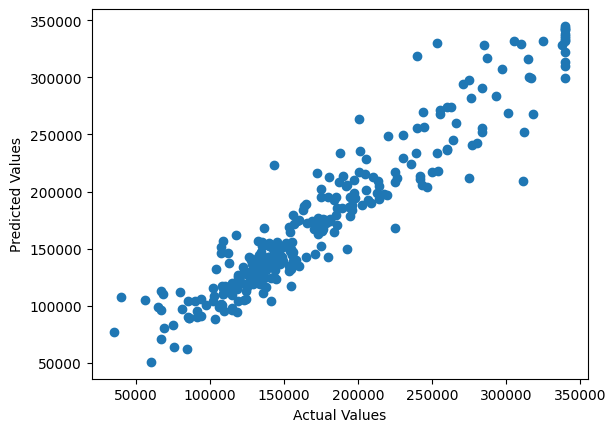

In [53]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()